# **Part 0 : Deliverable Guidelines**

The deliverable must consist of:
- One single `.ipynb` notebook (Python notebook)
- A PDF version exported from the notebook
- If possible, the dataset used should also be attached, or the data source should be clearly referenced in the notebook

https://huggingface.co/datasets/FinanceInc/auditor_sentiment

## **Timeline**

The final deliverable is expected **??**.



**Data Requirements**
The data must be taken from **Hugging Face**, and the topic must be related to:
- Finance
- Insurance
- Risk

## **Expectations**

You are expected to clearly explain the context and justify **why this use case is relevant**.

## **Why this problem?**


Explain:
- What the problem is
- Why it matters
- Why it is worth studying

## **What is the data?**

Explain:
- What the dataset is
- Why this dataset was chosen
- How the data is prepared
- Why the data is suitable for the problem

## **Supervised Model**


You must build a **supervised learning model** using the chosen data type, such as:
- Image
- Audio
- Text
- etc.

Minimum expected:
- Decision Tree  
**or**
- Random Forest

## **Study and Interpretation of Results ⭐ (Most Important)**


You are expected to analyze and interpret the model results:

- Is the model performance satisfactory?
- How can the results be interpreted?
- Why are the results good or bad?
- What could have been improved?
- What are the limitations of the results?
- Are there any constraints such as:
  - High model cost
  - Ethical risks
  - Bias
  - Practical limitations

## **Evaluation Criteria**

- **6 to 8 points** → Quality of explanations  
- **2 points** → Quality of code  
- **4 to 6 points** → Depth of the work  
- **6 to 8 points** → Respect of instructions and requirements  

# **Part 1 : Data Preperation**

## **1.1 - Import Data Set**

We first found and imported our auditor_sentiment data set from hungging face by connecting to our account with a token.

In [3]:
from datasets import load_dataset
ds = load_dataset("Tydyannes69/auditor_sentiment")

C:\Users\speed\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Then we wanted to have a look at the data set to see if the importation functioned. So we decided to create a CSV file to be able to visulize it. The data base was already separated in two different data set. A "Train" and "Test" data set. We decided to keep it this way, so we could train our model on the "Train" data set and then measure the quality of our trained model on the "Test" data set.

In [5]:
import pandas as pd

df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

print(df_train.head())
print(df_test.columns)

df_train.to_csv("train.csv", index=False)
df_test.to_csv("test.csv", index=False)



                                            sentence  label
0  Altia 's operating profit jumped to EUR 47 mil...      2
1  The agreement was signed with Biohit Healthcar...      2
2  Kesko pursues a strategy of healthy , focused ...      2
3  Vaisala , headquartered in Helsinki in Finland...      1
4  Also , a six-year historic analysis is provide...      1
Index(['sentence', 'label'], dtype='object')


## **1.2 - Descriptive Statistics**

Before doing any descriptive statistics we wanted to combine the "train" and "test" dataset to be able to study our entire dataset

In [6]:
df_combined = pd.concat([df_train, df_test], ignore_index=True)

In [7]:
# Nombre de lignes et colonnes
num_rows = df_combined.shape[0]
num_cols = df_combined.shape[1]

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"Names of the Columns: {ds['train'].column_names}")

Number of rows: 4846
Number of columns: 2
Names of the Columns: ['sentence', 'label']


### Transformation of the variable "label"

In [8]:
df_combined["label_num"] = df_combined["label"].map({
    0: "negative",
    1: "neutral",
    2: "positive"
})

### Description of the variable "label"

In [9]:
print("Distribution des classes :")
print(df_combined["label_num"].value_counts())

print("\nProportions (%) :")
print((df_combined["label_num"].value_counts(normalize=True) * 100).round(2))

Distribution des classes :
label_num
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Proportions (%) :
label_num
neutral     59.41
positive    28.13
negative    12.46
Name: proportion, dtype: float64


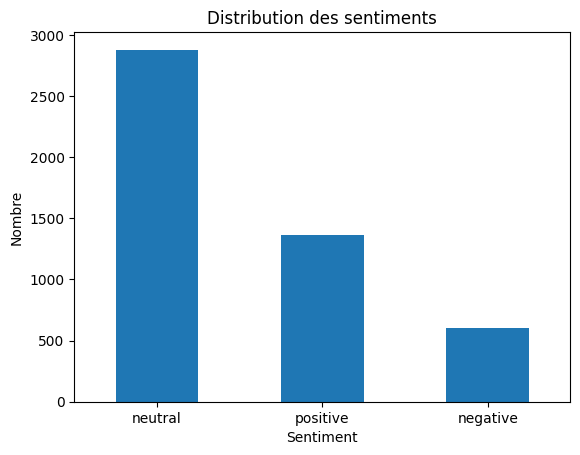

In [10]:
import matplotlib.pyplot as plt

df_combined["label_num"].value_counts().plot(kind="bar")
plt.title("Distribution des sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Nombre")
plt.xticks(rotation=0)
plt.show()

## **1.3 - Data Cleaning**

### Text Cleaning

We used the libraries NLTK and SpaCy for text processing and analysis. SpaCy (en_core_web_sm) facilitates advanced tasks such as lemmatization and syntactic analysis. Common words (stopwords) are removed in order to focus on and analyze the most meaningful terms.

Before converting raw text into usable data with CountVectorizer and TfidfVectorizer, it is necessary to clean the data. We therefore decided to standardize the text by converting it to lowercase, then removing special characters, numbers, and extra spaces.

In [15]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Stopwords anglais
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # suppression des stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\speed\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Lemmatize Text

Lemmatization reduces each word to its base form (e.g., “studying” becomes “study”). This reduces the complexity of the vocabulary while preserving the meaning of sentences.

We chose to lemmatize the textual variable "sentence", as it contains longer and meaningful sentences that are important for predicting our target variable.

We chose lemmatization rather than stemming because lemmatization preserves the meaning of words.

Finally, we applied lemmatization before vectorization to prevent the model from considering words like “study”, “studies”, and “studying” as three different terms. By doing so, we reduce computation time and improve the relevance of the results.

In [16]:
import spacy

# Charger modèle anglais
nlp = spacy.load("en_core_web_sm")

def lemmatize_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_punct]
    return " ".join(tokens)

Data cleaning and lemmatizing text on train et test dataset

In [18]:
df_train["sentence_clean"] = df_train["sentence"].apply(clean_text).apply(lemmatize_text)
df_test["sentence_clean"] = df_test["sentence"].apply(clean_text).apply(lemmatize_text)

### Vectorizing Text

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(df_train["sentence_clean"])
X_test_tfidf = tfidf_vectorizer.transform(df_test["sentence_clean"])

print(tfidf_vectorizer.get_feature_names_out()[:20])
print(X_train_tfidf)
print(X_test_tfidf)

['aaland' 'aalborg' 'aalto' 'aaltonen' 'aazhang' 'ab' 'abb' 'abbott' 'abc'
 'aberration' 'abidjan' 'ability' 'able' 'abloy' 'abn' 'aboavista' 'abp'
 'abroad' 'absentee' 'absolut']
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 43253 stored elements and shape (3877, 7042)>
  Coords	Values
  (0, 214)	0.5292005631474113
  (0, 4273)	0.30126907054538116
  (0, 4823)	0.22531735014614732
  (0, 3089)	0.45799119223200646
  (0, 1932)	0.3652281709093891
  (0, 3823)	0.48504458953006674
  (1, 137)	0.16809855813605745
  (1, 5639)	0.17951301589017268
  (1, 644)	0.48390418596677354
  (1, 2559)	0.25642549182009927
  (1, 3535)	0.19639378477055386
  (1, 6520)	0.30591036929128546
  (1, 5988)	0.1889300870974981
  (1, 4381)	0.14392423420912184
  (1, 2132)	0.11669359769172952
  (1, 4882)	0.22197616328649697
  (1, 1137)	0.09604996648570736
  (1, 1518)	0.18003413162204263
  (1, 3624)	0.19557315567158542
  (1, 3652)	0.14099370370818312
  (1, 3450)	0.24195209298338677
  (1, 2506)	0.23398680681837
 

Top 5 words that come up the most

In [23]:
import numpy as np

# moyenne des scores TF-IDF pour chaque mot (colonne)
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

# récupérer les mots
feature_names = tfidf_vectorizer.get_feature_names_out()

# trier du plus important au moins important
top_indices = mean_tfidf.argsort()[::-1]

# afficher les 5 mots les plus importants
for i in top_indices[:5]:
    print(feature_names[i], mean_tfidf[i])

eur 0.045490795293407396
mn 0.029129433135785292
company 0.02583569156855198
sale 0.019852040771930934
profit 0.017960670865058117


### Dimension Reduction

In [24]:
from sklearn.decomposition import TruncatedSVD

# Réduction de dimension
svd = TruncatedSVD(n_components=170, random_state=42)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape)
print(X_test_svd.shape)

(3877, 170)
(969, 170)


# **Part 2 : Classifier**

## **2.1 - Logistic Regression**

Training Model

In [28]:
y_train = df_train["label"]
y_test = df_test["label"]

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_svd, y_train)

y_pred = clf.predict(X_test_svd)

Testing Model

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7048503611971104
              precision    recall  f1-score   support

           0       0.67      0.31      0.43       124
           1       0.70      0.95      0.81       559
           2       0.73      0.39      0.51       286

    accuracy                           0.70       969
   macro avg       0.70      0.55      0.58       969
weighted avg       0.71      0.70      0.67       969

[[ 39  63  22]
 [  6 533  20]
 [ 13 162 111]]


# a FAIRE A LA FIN, tester avec meme modele mais en ne supprimant pas les mot de négation, car dans le lemmatisation et notayage il le fait. DOnc rajouter ca : 
negations = {"not", "no", "never"}

tokens = [
    token.lemma_ for token in doc
    if (token.text not in stop_words or token.text in negations)
    and not token.is_punct
]

# Ensuite tester d'autre modele qui comprenne la diff entre "win" et not "win" : 
# Word2Vec
# BERT
# Transformers

Comparér accuracy score et choisir